# Simulation 3: PDA auf bestehendem Modell

Nach dem Durchbruch in Sim 2b: Mean-Separation loest das Subspace-Problem.
Hier testen wir systematisch, wie weit PDA auf einem bestehenden Modell gehen kann.

**Experimente:**
- A: Multi-Layer PDA Pipeline
- B: Energieminimierung auf echten Subspaces
- C: Text-Output-Qualitaet
- D: Layer-Profiling (alle Layer)
- E: Signalmetriken als Qualitaetspraediktor

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
import gc

gc.collect()
torch.cuda.empty_cache()

sys.path.append(".")
sys.path.append(os.path.join("..", "simulation-1"))

import sim3_pipeline as pipeline
import sim3_energy as energy
import sim3_metrics as metrics

from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained(
    "Qwen/Qwen3-0.6B",
    device="cuda" if torch.cuda.is_available() else "cpu",
    trust_remote_code=True,
    dtype=torch.float32
)
n_layers = model.cfg.n_layers
d_model = model.cfg.d_model
print(f"Modell: {model.cfg.model_name}, {n_layers} Layer, d_model={d_model}")

# Prompts
prompts_facts = [
    "The capital of France is Paris.",
    "The chemical symbol for water is H2O.",
    "Einstein is known for the theory of relativity.",
    "The sun is a star in the center of the solar system.",
    "Humans breathe oxygen to survive."
]
prompts_reasoning = [
    "If A > B and B > C, then A must be greater than C.",
    "To solve x + 5 = 10, we subtract 5 from both sides.",
    "The next number in the sequence 2, 4, 8, 16 is 32.",
    "A triangle with three equal sides is called equilateral.",
    "If it rains, the ground gets wet. It is raining, so the ground is wet."
]
prompts_creative = [
    "Once upon a time in a galaxy far, far away,",
    "The neon lights of the city reflected in the puddles,",
    "A giant clockwork dragon roared over the mountain peak,",
    "The secret of the universe was hidden in a small tea cup,",
    "Music filled the air as the stars began to dance."
]
all_prompts = prompts_facts + prompts_reasoning + prompts_creative
tokens = model.to_tokens(all_prompts)
print(f"{len(all_prompts)} Prompts, tokens shape: {tokens.shape}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer
Modell: Qwen3-0.6B, 28 Layer, d_model=1024
15 Prompts, tokens shape: torch.Size([15, 23])


## Exp D: Layer-Profiling (zuerst, informiert alle anderen Experimente)

Welche Layer eignen sich am besten fuer PDA? Systematisches Profiling.

In [2]:
print("Profiling aller Layer (k=2)...")
print("Das dauert ein paar Minuten.\n")

layer_profile = pipeline.profile_all_layers(model, tokens, k=2)

# Ergebnis-Tabelle
print(f"\n{'Layer':>5} {'PR orig':>8} {'PR resid':>9} {'Dom %':>7} {'SV ratio':>9} {'CosSim':>8}")
print("-" * 50)
for l in sorted(layer_profile.keys()):
    p = layer_profile[l]
    print(f"{l:5d} {p['pr_original']:8.1f} {p['pr_residual']:9.1f} {p['dominant_var_share']:7.1%} "
          f"{p['sv_ratio']:9.1f} {p['cos_sim']:8.4f}")

Profiling aller Layer (k=2)...
Das dauert ein paar Minuten.

  Layer  0: PR 70.4->126.3, dom=53.5%, cos=0.9637
  Layer  5: PR 1.3->117.3, dom=100.0%, cos=0.9402
  Layer 10: PR 1.5->119.3, dom=100.0%, cos=0.9342
  Layer 15: PR 1.8->140.3, dom=99.9%, cos=0.9286
  Layer 20: PR 4.2->145.2, dom=99.2%, cos=0.9333
  Layer 25: PR 9.9->144.2, dom=96.7%, cos=0.9748

Layer  PR orig  PR resid   Dom %  SV ratio   CosSim
--------------------------------------------------
    0     70.4     126.3   53.5%       3.3   0.9637
    1     80.4     125.1   45.0%       2.3   0.3369
    2      1.2      94.5  100.0%     201.6   0.9392
    3      1.2     111.6  100.0%     199.7   0.9400
    4      1.2     118.6  100.0%     210.9   0.9339
    5      1.3     117.3  100.0%     158.9   0.9402
    6      1.3     122.6  100.0%     154.9   0.9420
    7      1.3     121.5  100.0%     151.1   0.9389
    8      1.4     130.3  100.0%     143.3   0.9355
    9      1.4     126.9  100.0%     119.9   0.9287
   10      1.5    

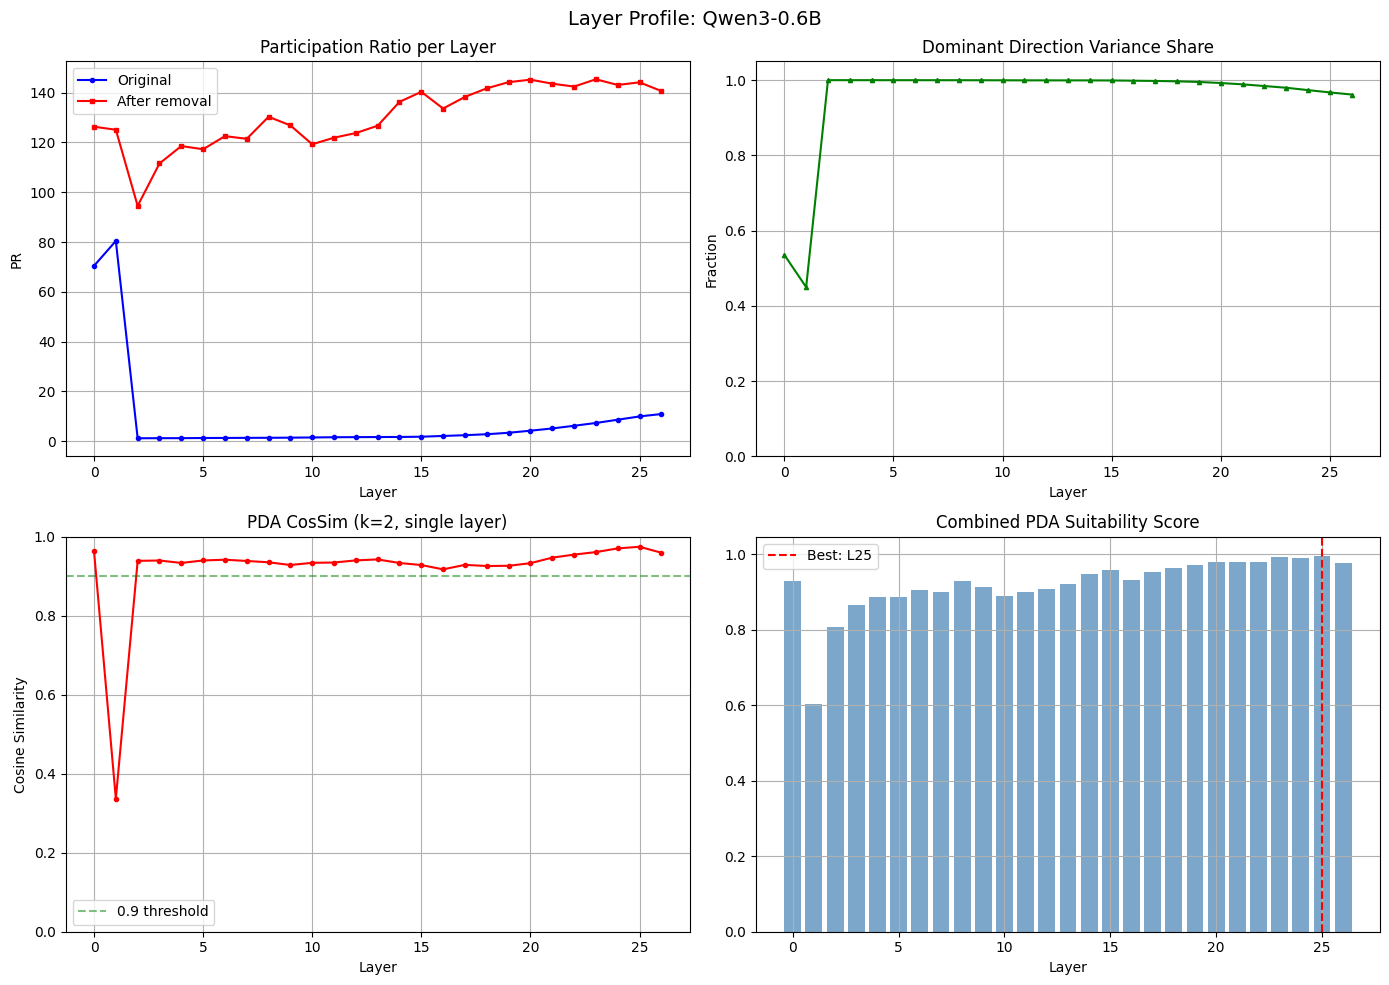


Top 5 Layer fuer PDA (nach CosSim): [25, 24, 0, 23, 26]
Bester Layer (combined score): 25


In [3]:
# Visualisierung
layers = sorted(layer_profile.keys())
pr_orig = [layer_profile[l]['pr_original'] for l in layers]
pr_resid = [layer_profile[l]['pr_residual'] for l in layers]
dom_var = [layer_profile[l]['dominant_var_share'] for l in layers]
cos_sims = [layer_profile[l]['cos_sim'] for l in layers]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(layers, pr_orig, 'b-o', markersize=3, label='Original')
axes[0, 0].plot(layers, pr_resid, 'r-s', markersize=3, label='After removal')
axes[0, 0].set_title('Participation Ratio per Layer')
axes[0, 0].set_xlabel('Layer')
axes[0, 0].set_ylabel('PR')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(layers, dom_var, 'g-^', markersize=3)
axes[0, 1].set_title('Dominant Direction Variance Share')
axes[0, 1].set_xlabel('Layer')
axes[0, 1].set_ylabel('Fraction')
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(True)

axes[1, 0].plot(layers, cos_sims, 'r-o', markersize=3)
axes[1, 0].set_title('PDA CosSim (k=2, single layer)')
axes[1, 0].set_xlabel('Layer')
axes[1, 0].set_ylabel('Cosine Similarity')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='0.9 threshold')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Heatmap: combined score
scores = np.array([[layer_profile[l]['pr_residual'], layer_profile[l]['cos_sim']] for l in layers])
scores_norm = scores / scores.max(axis=0)  # normalize columns
combined = scores_norm.mean(axis=1)
axes[1, 1].bar(layers, combined, color='steelblue', alpha=0.7)
best_layer = layers[np.argmax(combined)]
axes[1, 1].axvline(x=best_layer, color='red', linestyle='--', label=f'Best: L{best_layer}')
axes[1, 1].set_title('Combined PDA Suitability Score')
axes[1, 1].set_xlabel('Layer')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle(f'Layer Profile: {model.cfg.model_name}', fontsize=14)
plt.tight_layout()
plt.show()

# Beste Layer identifizieren
top_layers = sorted(layers, key=lambda l: layer_profile[l]['cos_sim'], reverse=True)[:5]
print(f"\nTop 5 Layer fuer PDA (nach CosSim): {top_layers}")
print(f"Bester Layer (combined score): {best_layer}")

## Exp A: Multi-Layer PDA Pipeline

Kann PDA ueber mehrere konsekutive Layer funktionieren?

In [4]:
# Teste Multi-Layer PDA von verschiedenen Start-Layern
start_layers = top_layers[:3]  # Top 3 aus Profiling
n_layer_range = [1, 2, 3, 5]
k_values = [2, 3]

results_a = []

for start in start_layers:
    for n_l in n_layer_range:
        if start + n_l >= n_layers:
            continue
        for k in k_values:
            print(f"Start={start}, n_layers={n_l}, k={k}...", end=" ")
            try:
                result = pipeline.pda_forward_multi_layer(
                    model, tokens, start, n_l, k,
                    recompute_dominant_per_layer=True
                )
                print(f"CosSim={result.cos_sim:.4f}")
                results_a.append({
                    "start": start,
                    "n_layers": n_l,
                    "k": k,
                    "cos_sim": result.cos_sim,
                    "mse": result.mse,
                    "per_layer_cos": result.per_layer_cos_sim,
                })
            except Exception as e:
                print(f"ERROR: {e}")

print(f"\n{len(results_a)} Konfigurationen getestet.")

Start=25, n_layers=1, k=2... CosSim=0.9748
Start=25, n_layers=1, k=3... CosSim=0.9533
Start=25, n_layers=2, k=2... CosSim=0.9030
Start=25, n_layers=2, k=3... CosSim=0.8636
Start=24, n_layers=1, k=2... CosSim=0.9707
Start=24, n_layers=1, k=3... CosSim=0.9458
Start=24, n_layers=2, k=2... CosSim=0.9383
Start=24, n_layers=2, k=3... CosSim=0.9124
Start=24, n_layers=3, k=2... CosSim=0.8674
Start=24, n_layers=3, k=3... CosSim=0.8404
Start=0, n_layers=1, k=2... CosSim=0.9637
Start=0, n_layers=1, k=3... CosSim=0.9173
Start=0, n_layers=2, k=2... CosSim=0.3821
Start=0, n_layers=2, k=3... CosSim=0.4095
Start=0, n_layers=3, k=2... CosSim=0.3955
Start=0, n_layers=3, k=3... CosSim=0.4095
Start=0, n_layers=5, k=2... CosSim=0.3742
Start=0, n_layers=5, k=3... CosSim=0.3872

18 Konfigurationen getestet.


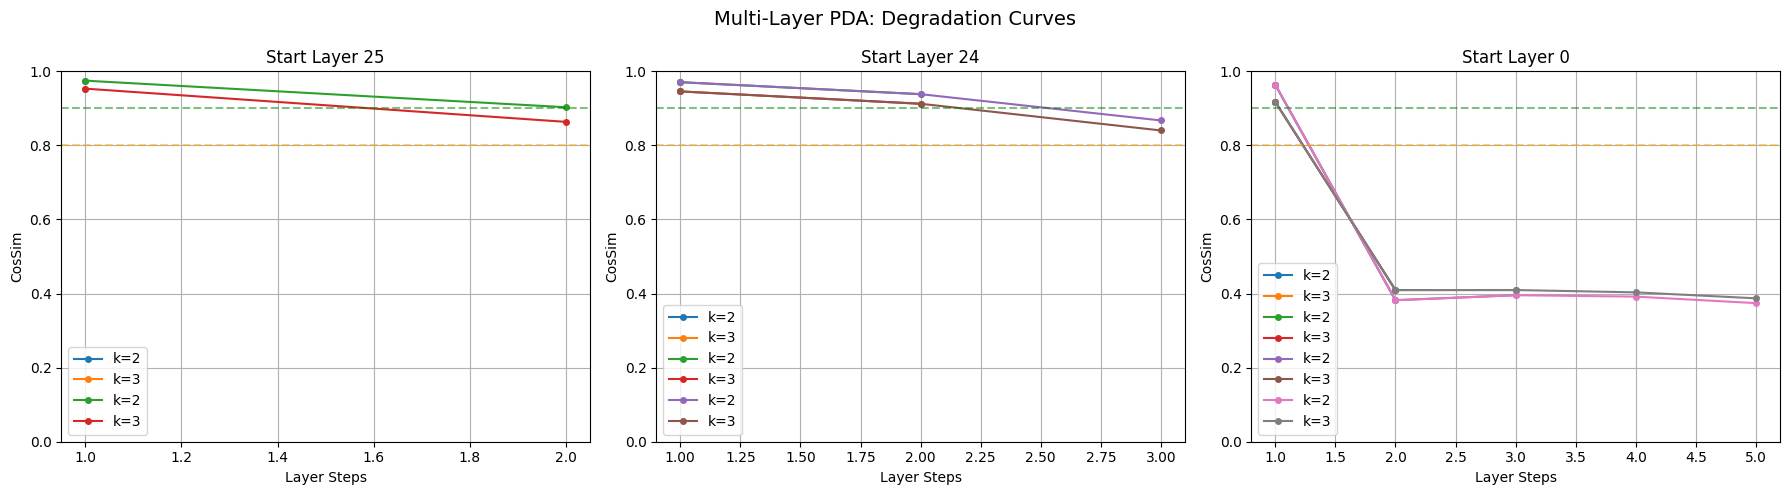

Start  nL  k Final CosSim  Degradation
--------------------------------------
   25   1  2       0.9748      +0.0000
   24   1  2       0.9707      +0.0000
    0   1  2       0.9637      +0.0000
   25   1  3       0.9533      +0.0000
   24   1  3       0.9458      +0.0000
   24   2  2       0.9383      +0.0323
    0   1  3       0.9173      +0.0000
   24   2  3       0.9124      +0.0333
   25   2  2       0.9030      +0.0718
   24   3  2       0.8674      +0.1033
   25   2  3       0.8636      +0.0897
   24   3  3       0.8404      +0.1054
    0   3  3       0.4095      +0.5077
    0   2  3       0.4095      +0.5078
    0   3  2       0.3955      +0.5682
    0   5  3       0.3872      +0.5301
    0   2  2       0.3821      +0.5816
    0   5  2       0.3742      +0.5895


In [5]:
# Degradationskurven: CosSim pro Layer
fig, axes = plt.subplots(1, len(start_layers), figsize=(6*len(start_layers), 5))
if len(start_layers) == 1:
    axes = [axes]

for idx, start in enumerate(start_layers):
    ax = axes[idx]
    for r in results_a:
        if r['start'] == start:
            label = f"k={r['k']}"
            steps = list(range(1, len(r['per_layer_cos']) + 1))
            ax.plot(steps, r['per_layer_cos'], '-o', label=label, markersize=4)
    ax.set_title(f"Start Layer {start}")
    ax.set_xlabel("Layer Steps")
    ax.set_ylabel("CosSim")
    ax.set_ylim(0, 1)
    ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5)
    ax.axhline(y=0.8, color='orange', linestyle='--', alpha=0.5)
    ax.legend()
    ax.grid(True)

plt.suptitle("Multi-Layer PDA: Degradation Curves", fontsize=14)
plt.tight_layout()
plt.show()

# Zusammenfassung
print(f"{'Start':>5} {'nL':>3} {'k':>2} {'Final CosSim':>12} {'Degradation':>12}")
print("-" * 38)
for r in sorted(results_a, key=lambda x: x['cos_sim'], reverse=True):
    first = r['per_layer_cos'][0] if r['per_layer_cos'] else 0
    last = r['cos_sim']
    deg = first - last if len(r['per_layer_cos']) > 1 else 0
    print(f"{r['start']:5d} {r['n_layers']:3d} {r['k']:2d} {last:12.4f} {deg:+12.4f}")

## Exp B: Energieminimierung auf echten Subspaces

Kann Energy Minimization (aus Sim 1) den Merge verbessern?

In [6]:
# Besten Start-Layer aus Exp A/D nehmen
test_layer = top_layers[0]
print(f"Teste Energieminimierung an Layer {test_layer}\n")

# Aktivierungen holen
hook_name = f"blocks.{test_layer}.hook_resid_post"
out_hook = f"blocks.{test_layer+1}.hook_resid_post"
with torch.no_grad():
    _, cache = model.run_with_cache(tokens, names_filter=[hook_name, out_hook])
    acts = cache[hook_name].detach().cpu()
    ground_truth = cache[out_hook].detach().cpu()
    del cache
    torch.cuda.empty_cache()

# PDA forward fuer verschiedene k, mit und ohne Energy
results_b = {"k": [], "cos_avg": [], "cos_energy": [], "iterations": [], "snr_final": []}

for k in [2, 3, 4, 5]:
    print(f"\nk={k}:")
    
    # Forward ohne Energy (Average Merge)
    dom = pipeline.compute_dominant_direction(acts)
    dominant, residual = pipeline.separate_dominant(acts, dom)
    subspaces = pipeline.decompose_residual_subspaces(residual, k)
    
    # Forward each subspace through next layer
    sub_outputs = []
    for i, sub in enumerate(subspaces):
        sub_act = (dominant + sub).to(model.cfg.device)
        captured = {}
        def make_hook(a):
            def h(v, hook): return a
            return h
        def make_cap(s):
            def c(v, hook): s['out'] = v.detach().cpu(); return v
            return c
        with torch.no_grad():
            model.run_with_hooks(tokens, fwd_hooks=[
                (hook_name, make_hook(sub_act)),
                (out_hook, make_cap(captured))
            ])
        sub_outputs.append(captured['out'])
        torch.cuda.empty_cache()
    
    # Average merge
    merged_avg = torch.stack(sub_outputs).mean(dim=0)
    cos_avg = torch.nn.functional.cosine_similarity(
        merged_avg.reshape(-1, d_model), ground_truth.reshape(-1, d_model), dim=1
    ).mean().item()
    
    # Energy-minimized merge
    merged_e, hist = energy.merge_with_energy(sub_outputs, lr=0.1, max_iter=30, verbose=True)
    cos_e = torch.nn.functional.cosine_similarity(
        merged_e.reshape(-1, d_model), ground_truth.reshape(-1, d_model), dim=1
    ).mean().item()
    
    print(f"  Average:  CosSim={cos_avg:.4f}")
    print(f"  Energy:   CosSim={cos_e:.4f} ({cos_e-cos_avg:+.4f}), "
          f"{hist['iterations']} iter, halted by {hist['halted_by']}")
    
    results_b["k"].append(k)
    results_b["cos_avg"].append(cos_avg)
    results_b["cos_energy"].append(cos_e)
    results_b["iterations"].append(hist['iterations'])
    results_b["snr_final"].append(hist['snr'][-1] if hist['snr'] else 0)

Teste Energieminimierung an Layer 25


k=2:
  Iter   0: E=60.709896, SNR=21.09dB, Coh=0.5032
  Average:  CosSim=0.9748
  Energy:   CosSim=0.9748 (+0.0000), 1 iter, halted by snr>=10.0

k=3:
  Iter   0: E=40.473264, SNR=21.58dB, Coh=0.5100
  Average:  CosSim=0.9533
  Energy:   CosSim=0.9533 (+0.0000), 1 iter, halted by snr>=10.0

k=4:
  Iter   0: E=30.356308, SNR=22.32dB, Coh=0.3449
  Average:  CosSim=0.9398
  Energy:   CosSim=0.9398 (+0.0000), 1 iter, halted by snr>=10.0

k=5:
  Iter   0: E=24.299727, SNR=23.00dB, Coh=0.4313
  Average:  CosSim=0.9309
  Energy:   CosSim=0.9309 (+0.0000), 1 iter, halted by snr>=10.0


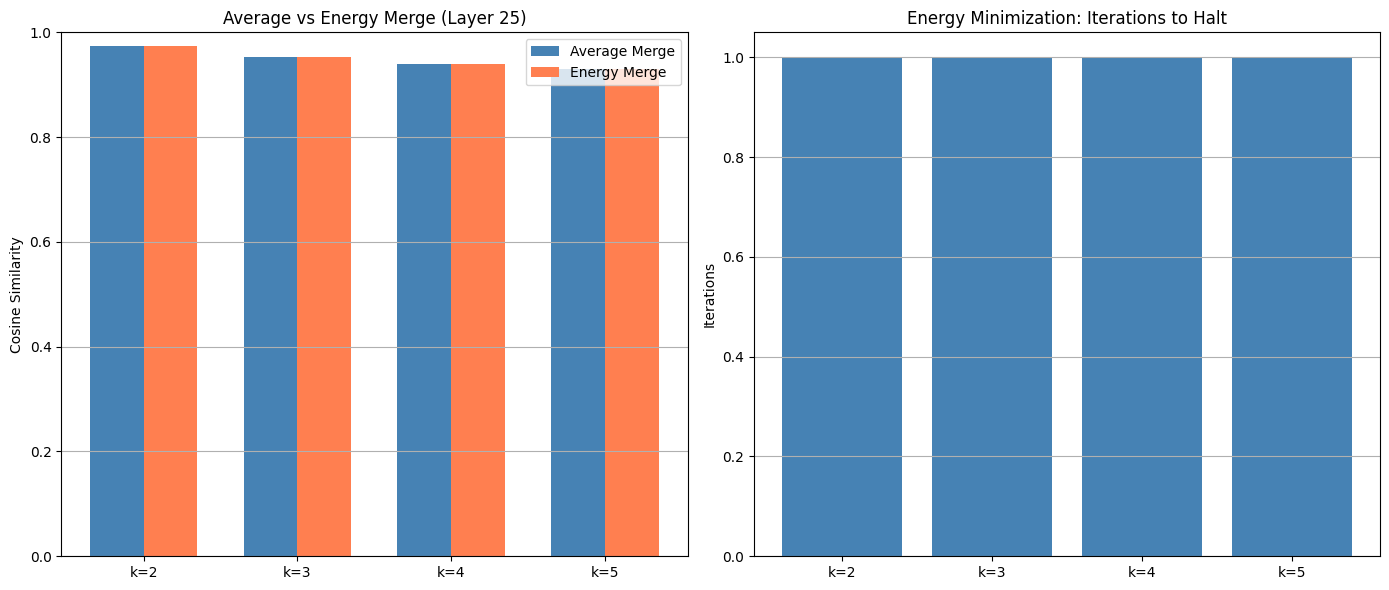

In [7]:
# Visualisierung: Average vs Energy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(results_b['k']))
w = 0.35
ax1.bar(x - w/2, results_b['cos_avg'], w, label='Average Merge', color='steelblue')
ax1.bar(x + w/2, results_b['cos_energy'], w, label='Energy Merge', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels([f"k={k}" for k in results_b['k']])
ax1.set_ylabel('Cosine Similarity')
ax1.set_title(f'Average vs Energy Merge (Layer {test_layer})')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True, axis='y')

ax2.bar(x, results_b['iterations'], color='steelblue')
ax2.set_xticks(x)
ax2.set_xticklabels([f"k={k}" for k in results_b['k']])
ax2.set_ylabel('Iterations')
ax2.set_title('Energy Minimization: Iterations to Halt')
ax2.grid(True, axis='y')

plt.tight_layout()
plt.show()

## Exp C: Text-Output-Qualitaet

Der eigentliche Test: produziert PDA sinnvollen Text?

In [8]:
# Bester Layer und k aus vorherigen Experimenten
best_start = top_layers[0]
best_k = 2  # Start konservativ

# Original logits
with torch.no_grad():
    original_logits = model(tokens)

# PDA logits: hook-basiert, Mean-Separated, single layer
def get_pda_logits(model, tokens, layer_idx, k):
    """Run full forward pass with PDA at one layer, return final logits."""
    hook_name = f"blocks.{layer_idx}.hook_resid_post"
    
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=[hook_name])
        acts = cache[hook_name].detach().cpu()
        del cache
        torch.cuda.empty_cache()
    
    # PDA: mean-separated forward
    merged, dom, stats = pipeline.pda_forward_single_layer(
        model, acts, layer_idx, k, tokens
    )
    
    # Run merged through rest of model
    def inject_hook(act):
        def h(v, hook): return act.to(model.cfg.device)
        return h
    
    out_hook = f"blocks.{layer_idx+1}.hook_resid_post"
    with torch.no_grad():
        pda_logits = model.run_with_hooks(
            tokens,
            fwd_hooks=[(out_hook, inject_hook(merged))]
        )
    return pda_logits

print(f"PDA an Layer {best_start}, k={best_k}...")
pda_logits = get_pda_logits(model, tokens, best_start, best_k)

# Qualitaetsmetriken
quality = metrics.compute_output_quality_suite(model, tokens, original_logits, pda_logits)

print(f"\n{'='*50}")
print(f"Output-Qualitaet (Layer {best_start}, k={best_k})")
print(f"{'='*50}")
for key, val in quality.items():
    print(f"  {key:<25} {val:.4f}")

PDA an Layer 25, k=2...

Output-Qualitaet (Layer 25, k=2)
  kl_divergence             0.4718
  top1_match                0.6058
  top5_overlap              0.6846
  top10_overlap             0.6530
  perplexity_original       1436.3217
  perplexity_pda            2400.3491
  perplexity_ratio          1.6712


Layer 25, k=2... Top1=0.606, KL=0.4718, PPL_ratio=1.67
Layer 25, k=3... Top1=0.394, KL=1.1303, PPL_ratio=2.83
Layer 25, k=5... Top1=0.203, KL=2.0316, PPL_ratio=5.93
Layer 24, k=2... Top1=0.675, KL=0.4081, PPL_ratio=1.23
Layer 24, k=3... Top1=0.501, KL=1.0223, PPL_ratio=1.93
Layer 24, k=5... Top1=0.342, KL=1.9042, PPL_ratio=3.99
Layer 0, k=2... Top1=0.542, KL=0.6742, PPL_ratio=0.64
Layer 0, k=3... Top1=0.261, KL=2.4872, PPL_ratio=1.90
Layer 0, k=5... Top1=0.159, KL=3.4833, PPL_ratio=4.95


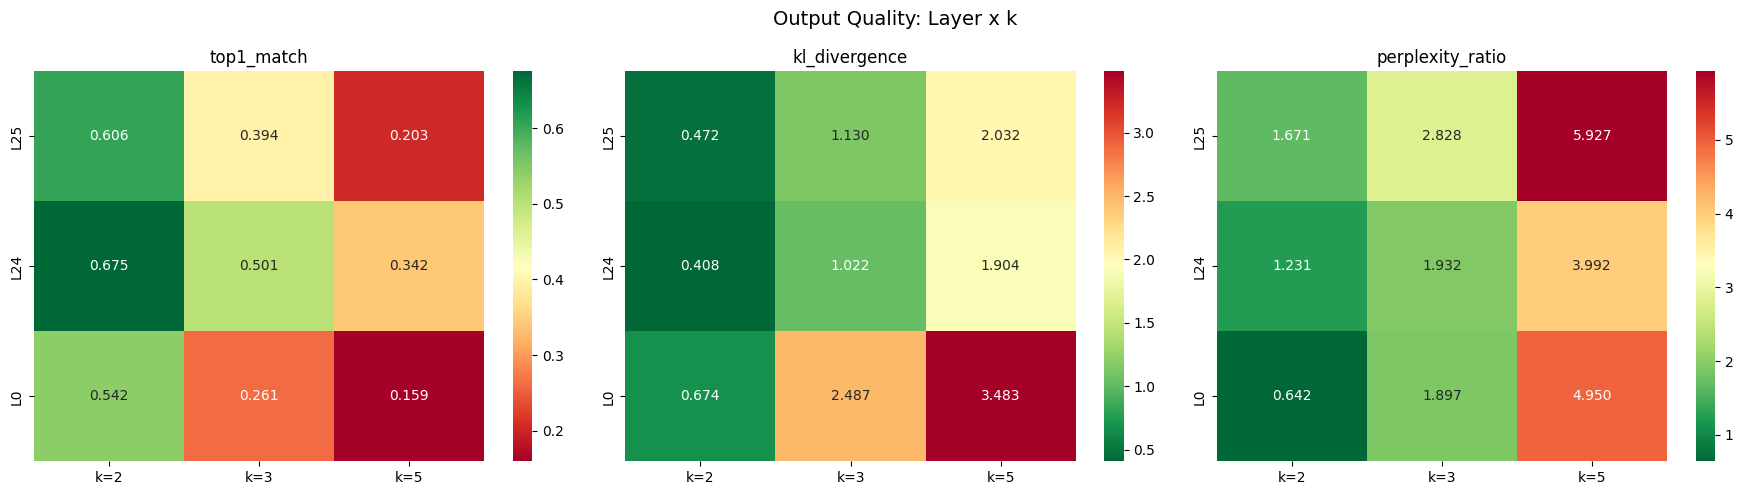

In [9]:
# Sweep: verschiedene Layer und k Werte
test_layers = top_layers[:3]
test_ks = [2, 3, 5]

results_c = []
for l in test_layers:
    for k in test_ks:
        print(f"Layer {l}, k={k}...", end=" ")
        try:
            pl = get_pda_logits(model, tokens, l, k)
            q = metrics.compute_output_quality_suite(model, tokens, original_logits, pl)
            q['layer'] = l
            q['k'] = k
            results_c.append(q)
            print(f"Top1={q['top1_match']:.3f}, KL={q['kl_divergence']:.4f}, PPL_ratio={q['perplexity_ratio']:.2f}")
        except Exception as e:
            print(f"ERROR: {e}")

# Heatmap
if results_c:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, metric_name in enumerate(['top1_match', 'kl_divergence', 'perplexity_ratio']):
        data = np.zeros((len(test_layers), len(test_ks)))
        for r in results_c:
            i = test_layers.index(r['layer'])
            j = test_ks.index(r['k'])
            data[i, j] = r[metric_name]
        
        sns.heatmap(data, annot=True, fmt='.3f', ax=axes[idx],
                    xticklabels=[f"k={k}" for k in test_ks],
                    yticklabels=[f"L{l}" for l in test_layers],
                    cmap='RdYlGn' if metric_name == 'top1_match' else 'RdYlGn_r')
        axes[idx].set_title(metric_name)
    
    plt.suptitle('Output Quality: Layer x k', fontsize=14)
    plt.tight_layout()
    plt.show()

In [10]:
# Qualitative Beispiele: generierter Text vergleichen
test_prompts_gen = [
    "The meaning of life is",
    "To solve this problem, we need to",
    "Once upon a time, there was a",
    "The most important thing about programming is",
    "In the year 2050, humanity will",
]

print("Textvergleich: Normal vs PDA\n")
for prompt in test_prompts_gen:
    # Normal
    normal = metrics.generate_and_compare(model, prompt, n_tokens=20)
    
    # PDA: single-layer at best layer
    pda_tokens_input = model.to_tokens(prompt)
    pda_generated = pda_tokens_input.clone()
    
    for step in range(20):
        hook_name = f"blocks.{best_start}.hook_resid_post"
        with torch.no_grad():
            _, cache = model.run_with_cache(pda_generated, names_filter=[hook_name])
            acts = cache[hook_name].detach().cpu()
            del cache
            torch.cuda.empty_cache()
        
        merged, _, _ = pipeline.pda_forward_single_layer(
            model, acts, best_start, best_k, pda_generated
        )
        
        out_hook = f"blocks.{best_start+1}.hook_resid_post"
        def inject(act):
            def h(v, hook): return act.to(model.cfg.device)
            return h
        with torch.no_grad():
            pda_logits_step = model.run_with_hooks(
                pda_generated,
                fwd_hooks=[(out_hook, inject(merged))]
            )
        next_token = pda_logits_step[0, -1].argmax()
        pda_generated = torch.cat([pda_generated, next_token.unsqueeze(0).unsqueeze(0)], dim=1)
    
    pda_text = model.to_string(pda_generated[0])
    
    print(f"Prompt: {prompt}")
    print(f"Normal: {normal['normal_text']}")
    print(f"PDA:    {pda_text}")
    print()

Textvergleich: Normal vs PDA

Prompt: The meaning of life is
Normal: The meaning of life is a philosophical question that has long been debated by philosophers, scientists, and thinkers. It is a question
PDA:    The meaning of life is the most important thing in the world, and the most important thing in the world. The meaning of

Prompt: To solve this problem, we need to
Normal: To solve this problem, we need to find the value of $ x $ such that the function $ f(x) = \frac{1
PDA:    To solve this problem, we need to find the first two digits of the number $ 2 \times 10^{100

Prompt: Once upon a time, there was a
Normal: Once upon a time, there was a man who lived in a village called Elan. He had a lot of problems with his family,
PDA:    Once upon a time, there was a a a a a a a a a a a a a a a a a a a a a

Prompt: The most important thing about programming is
Normal: The most important thing about programming is to make it work. So, what is the most important thing about programming?

## Exp E: Signalmetriken als Qualitaetspraediktor

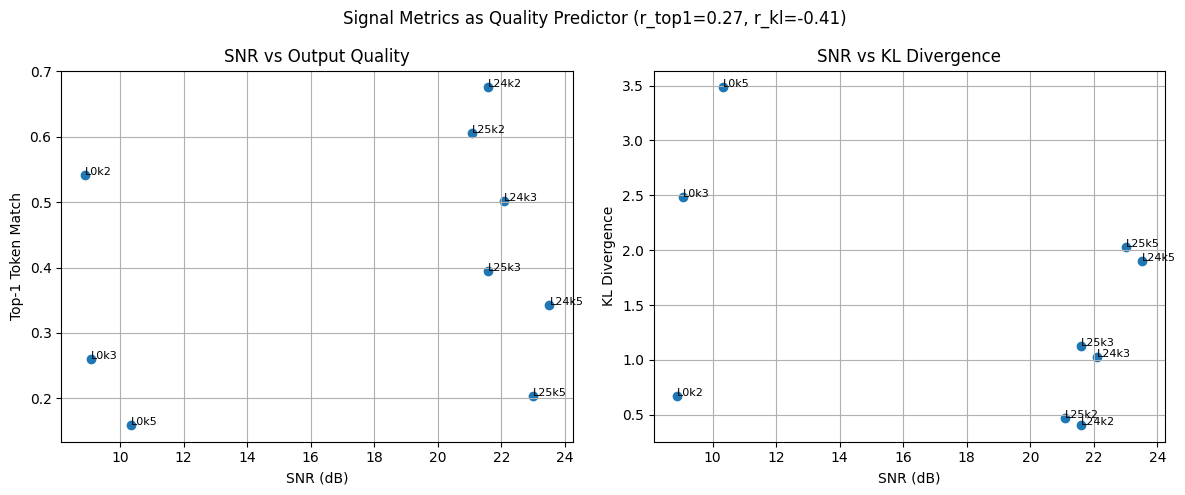

In [11]:
# Korrelation: Signalmetriken vs. Output-Qualitaet
# Fuer jede getestete Konfiguration aus Exp C: Signalmetriken berechnen

if results_c:
    signal_data = []
    for r in results_c:
        l, k = r['layer'], r['k']
        
        # Subspace outputs holen
        hook_name = f"blocks.{l}.hook_resid_post"
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=[hook_name])
            acts = cache[hook_name].detach().cpu()
            del cache
            torch.cuda.empty_cache()
        
        dom = pipeline.compute_dominant_direction(acts)
        dominant, residual = pipeline.separate_dominant(acts, dom)
        subspaces = pipeline.decompose_residual_subspaces(residual, k)
        
        # Forward each through next layer
        sub_outs = []
        out_hook = f"blocks.{l+1}.hook_resid_post"
        for sub in subspaces:
            sub_act = (dominant + sub).to(model.cfg.device)
            captured = {}
            def mh(a):
                def h(v, hook): return a
                return h
            def mc(s):
                def c(v, hook): s['out']=v.detach().cpu(); return v
                return c
            with torch.no_grad():
                model.run_with_hooks(tokens, fwd_hooks=[
                    (hook_name, mh(sub_act)), (out_hook, mc(captured))])
            sub_outs.append(captured['out'])
            torch.cuda.empty_cache()
        
        sig = energy.compute_signal_metrics(sub_outs)
        signal_data.append({
            'layer': l, 'k': k,
            'snr': sig['snr'],
            'coherence': sig['phase_coherence_mean'],
            'top1_match': r['top1_match'],
            'kl': r['kl_divergence'],
            'ppl_ratio': r['perplexity_ratio'],
        })
    
    # Korrelationsplot
    if len(signal_data) >= 3:
        snrs = [d['snr'] for d in signal_data]
        top1s = [d['top1_match'] for d in signal_data]
        kls = [d['kl'] for d in signal_data]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        ax1.scatter(snrs, top1s)
        for d in signal_data:
            ax1.annotate(f"L{d['layer']}k{d['k']}", (d['snr'], d['top1_match']), fontsize=8)
        ax1.set_xlabel('SNR (dB)')
        ax1.set_ylabel('Top-1 Token Match')
        ax1.set_title('SNR vs Output Quality')
        ax1.grid(True)
        
        ax2.scatter(snrs, kls)
        for d in signal_data:
            ax2.annotate(f"L{d['layer']}k{d['k']}", (d['snr'], d['kl']), fontsize=8)
        ax2.set_xlabel('SNR (dB)')
        ax2.set_ylabel('KL Divergence')
        ax2.set_title('SNR vs KL Divergence')
        ax2.grid(True)
        
        corr_top1 = np.corrcoef(snrs, top1s)[0,1]
        corr_kl = np.corrcoef(snrs, kls)[0,1]
        plt.suptitle(f'Signal Metrics as Quality Predictor (r_top1={corr_top1:.2f}, r_kl={corr_kl:.2f})')
        plt.tight_layout()
        plt.show()

## Zusammenfassung

In [12]:
print("=" * 70)
print("SIMULATION 3: ERGEBNIS-ZUSAMMENFASSUNG")
print("=" * 70)

print(f"\nModell: {model.cfg.model_name}, {n_layers} Layer")
print(f"Bester Layer fuer PDA: {best_start}")

print(f"\n--- Exp A: Multi-Layer ---")
if results_a:
    best_multi = max(results_a, key=lambda r: r['cos_sim'])
    worst_multi = min(results_a, key=lambda r: r['cos_sim'])
    print(f"  Bestes Ergebnis: L{best_multi['start']}, {best_multi['n_layers']}L, k={best_multi['k']} -> CosSim={best_multi['cos_sim']:.4f}")
    multi_3plus = [r for r in results_a if r['n_layers'] >= 3 and r['cos_sim'] > 0.8]
    print(f"  Konfigurationen mit 3+ Layern und CosSim>0.8: {len(multi_3plus)}")

print(f"\n--- Exp B: Energy Minimization ---")
for i, k in enumerate(results_b['k']):
    delta = results_b['cos_energy'][i] - results_b['cos_avg'][i]
    print(f"  k={k}: Avg={results_b['cos_avg'][i]:.4f}, Energy={results_b['cos_energy'][i]:.4f} ({delta:+.4f})")

print(f"\n--- Exp C: Output Quality ---")
if results_c:
    best_q = max(results_c, key=lambda r: r['top1_match'])
    print(f"  Bestes Top-1 Match: L{best_q['layer']}, k={best_q['k']} -> {best_q['top1_match']:.3f}")
    print(f"  Bestes KL:          {min(r['kl_divergence'] for r in results_c):.4f}")
    print(f"  Bestes PPL ratio:   {min(r['perplexity_ratio'] for r in results_c):.2f}")

print(f"\n{'='*70}")
print("ENTSCHEIDUNG:")

# Automatische Bewertung
best_top1 = max(r['top1_match'] for r in results_c) if results_c else 0
has_multi_layer = any(r['n_layers'] >= 3 and r['cos_sim'] > 0.8 for r in results_a) if results_a else False
energy_helps = any(results_b['cos_energy'][i] > results_b['cos_avg'][i] + 0.01 for i in range(len(results_b['k'])))

if best_top1 > 0.9 and has_multi_layer:
    print("  -> STARK POSITIV: PDA auf bestehendem Modell ist viable.")
    print("     Multi-Layer funktioniert, Output-Qualitaet hoch.")
elif best_top1 > 0.7:
    print("  -> POSITIV: PDA funktioniert als shallow parallelism.")
    print("     Tiefe Deliberation braucht vermutlich Training (Sim 4).")
else:
    print("  -> NEGATIV: Trotz guter CosSim produziert PDA keinen guten Output.")
    print("     CosSim auf Aktivierungen taeuscht. Weiter zu Sim 4.")

if energy_helps:
    print("  Energy Minimization verbessert den Merge messbar.")
else:
    print("  Energy Minimization bringt keinen signifikanten Vorteil.")

print(f"\nNAECHSTER SCHRITT: Sim 4 (Toy-Modell from scratch) als Vergleich")
print("=" * 70)

SIMULATION 3: ERGEBNIS-ZUSAMMENFASSUNG

Modell: Qwen3-0.6B, 28 Layer
Bester Layer fuer PDA: 25

--- Exp A: Multi-Layer ---
  Bestes Ergebnis: L25, 1L, k=2 -> CosSim=0.9748
  Konfigurationen mit 3+ Layern und CosSim>0.8: 2

--- Exp B: Energy Minimization ---
  k=2: Avg=0.9748, Energy=0.9748 (+0.0000)
  k=3: Avg=0.9533, Energy=0.9533 (+0.0000)
  k=4: Avg=0.9398, Energy=0.9398 (+0.0000)
  k=5: Avg=0.9309, Energy=0.9309 (+0.0000)

--- Exp C: Output Quality ---
  Bestes Top-1 Match: L24, k=2 -> 0.675
  Bestes KL:          0.4081
  Bestes PPL ratio:   0.64

ENTSCHEIDUNG:
  -> NEGATIV: Trotz guter CosSim produziert PDA keinen guten Output.
     CosSim auf Aktivierungen taeuscht. Weiter zu Sim 4.
  Energy Minimization bringt keinen signifikanten Vorteil.

NAECHSTER SCHRITT: Sim 4 (Toy-Modell from scratch) als Vergleich
